# Data Project - Stock Market Analysis

## I'll be answering the following questions along the way:
#### 1. What was the change in price of the stock over time?
#### 2. What was the daily return of the stock on average?
#### 3. What was the moving average of the various stocks?
#### 4. What was the correlation between different stocks' closing prices?
#### 5. What was the correlation between different stocks' daily returns?
#### 6. How much value do we put at risk by investing in a particular stock?
#### 7. How can we attempt to predict future stock behavior?

Note: I will provide insights down below each visualization


In [40]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pandas_datareader import DataReader

In [4]:
import yfinance as yf

In [5]:
from datetime import datetime
from datetime import datetime, timedelta

In [6]:
tech_list =['AAPL','GOOG','MSFT','AMZM']

In [7]:
# Set the start and end dates
end = datetime.today()
start = end - timedelta(days=365)  # 1 year ago

tech_list = ['AAPL', 'GOOGL', 'MSFT', 'AMZN']  # list of tech stocks that I am interested in tracking
stock_data = {}

for stock in tech_list:
    stock_data[stock] = yf.download(stock, start=start, end=end)
    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
# Take a quick look at AAPL stock 
stock_data['AAPL'].head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-22,192.944748,194.377730,191.322690,191.362503,60133900
2024-01-23,194.228455,194.795683,192.885045,194.069246,42355600
2024-01-24,193.551773,195.422613,193.392549,194.467286,53631300
2024-01-25,193.223389,195.313157,192.168559,194.268273,54822100
2024-01-26,191.481918,193.810507,191.004263,193.322905,44594000


In [9]:
stock_data['AAPL'].describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,209.310709,211.108364,207.322317,209.161962,5.669196e+07
std,26.035672,26.130238,25.657957,25.920148,3.094154e+07
min,164.405121,165.800067,163.488440,164.753864,2.323470e+07
25%,184.515640,186.222354,182.867252,185.041587,4.120708e+07
50%,218.177147,220.689535,216.052363,218.546312,4.966605e+07
75%,228.274998,229.927652,226.339797,228.437504,6.232015e+07
max,259.019989,260.100006,257.630005,258.190002,3.186799e+08


In [10]:
stock_data['AAPL'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-01-22 to 2025-01-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


Text(0.5, 1.0, 'Amazon (AMZN) Closing Prices Over Time')

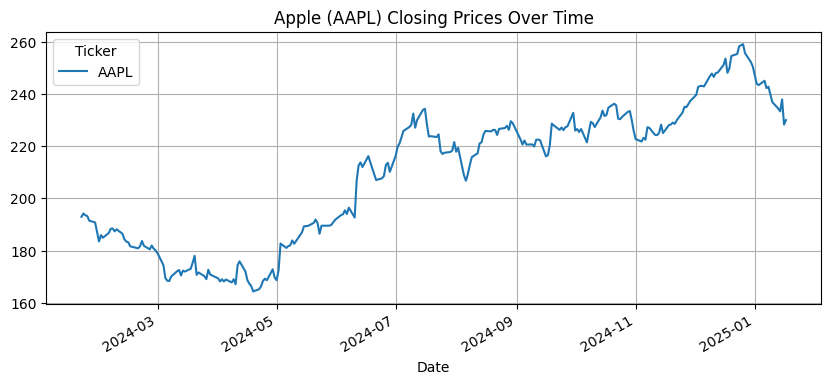

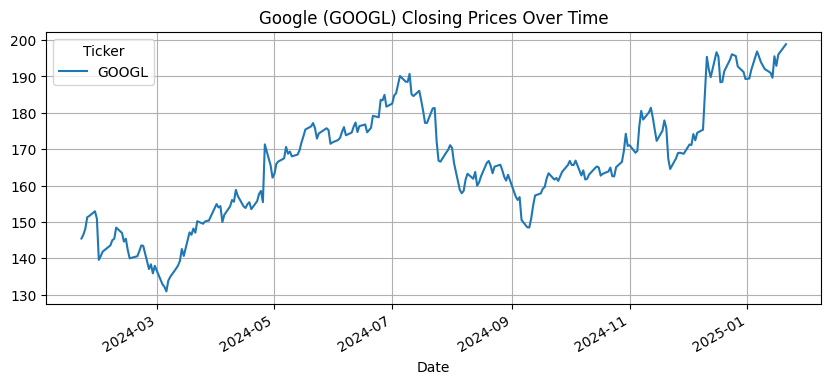

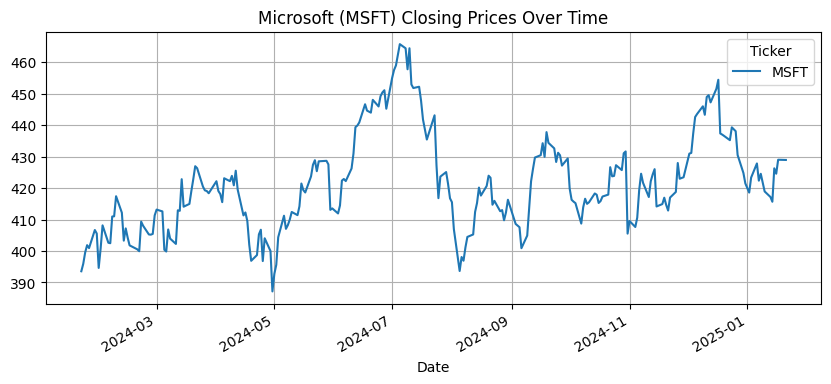

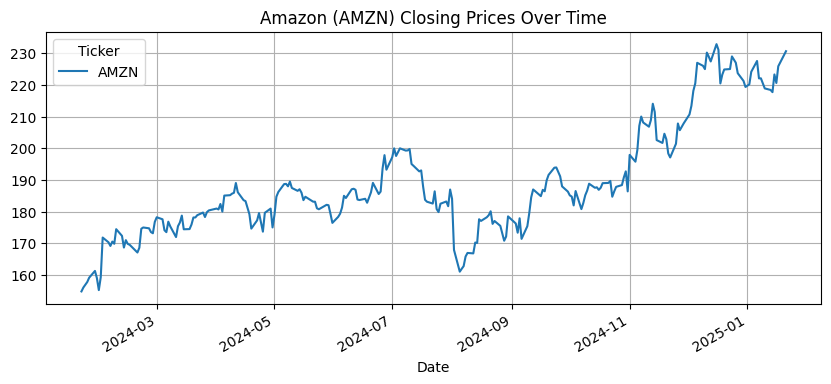

In [11]:
# Let's see a historical view of the closing price for AAPL
stock_data['AAPL']['Close'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Apple (AAPL) Closing Prices Over Time')
stock_data['GOOGL']['Close'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Google (GOOGL) Closing Prices Over Time')
stock_data['MSFT']['Close'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Microsoft (MSFT) Closing Prices Over Time')
stock_data['AMZN']['Close'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Amazon (AMZN) Closing Prices Over Time')

## Insights

- Although the closing price trends of the four target companies have shown significant fluctuations over the past year, they have generally experienced an upward trend. This indicates that the stock prices for these companies have appreciated over the observed period. 

=> The overall positive trend reflects investor confidence and grwoth potential for these companies

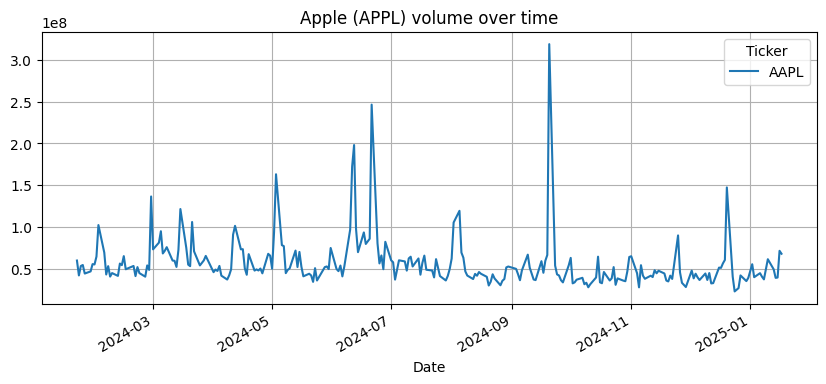

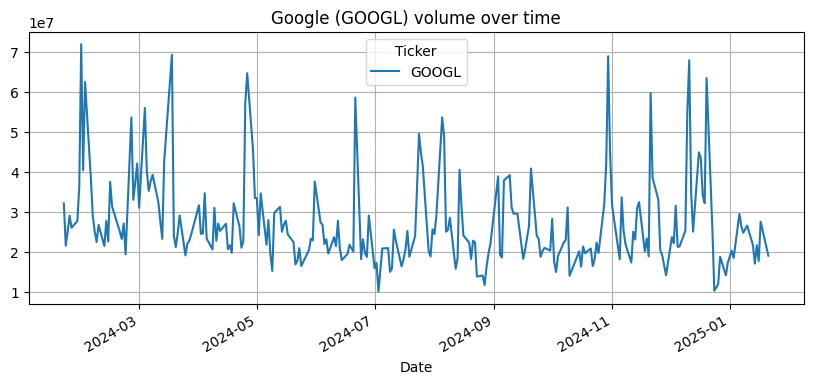

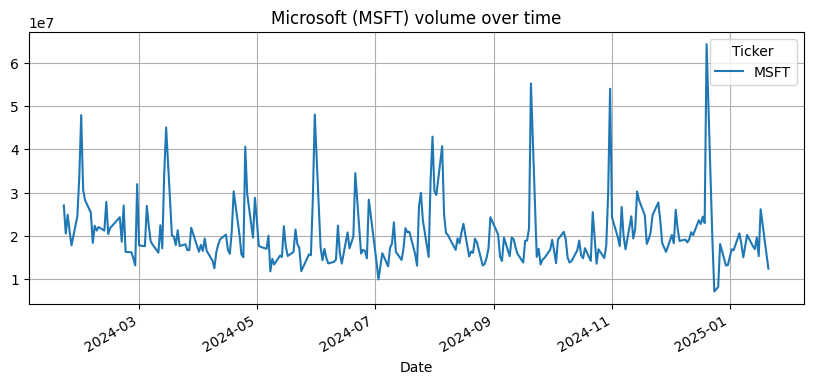

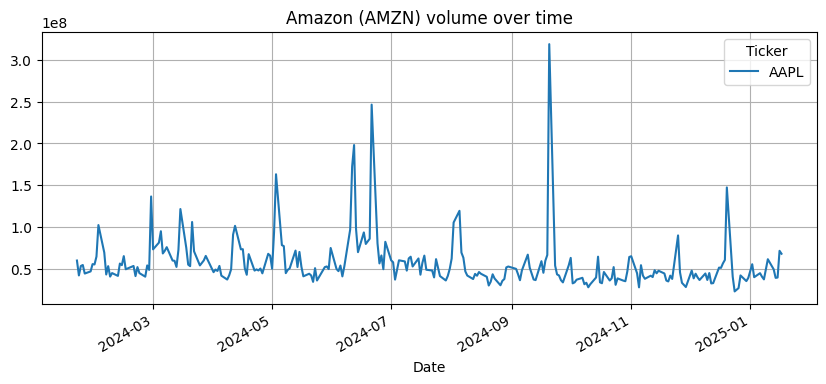

In [12]:
# Let's take a look at the total volume stock being traded over the past year
stock_data['AAPL']['Volume'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Apple (APPL) volume over time')
plt.show()

stock_data['GOOGL']['Volume'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Google (GOOGL) volume over time')
plt.show()

stock_data['MSFT']['Volume'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Microsoft (MSFT) volume over time')
plt.show()

stock_data['AAPL']['Volume'].plot(legend=True,figsize=(10,4)).grid(True)
plt.title('Amazon (AMZN) volume over time')
plt.show()

## Insights

- Apple and Amazon have experienced a simillar trend in stock volume over the past year. Both have increased in trading volume after March 2024 and followed by a decline during the last three months of the year. Their stock volumes peaked in early October.

- Google and Microsoft experienced more sharp fluctuations in their stock volumes throughout the year. Their volumes were consistently remaining above 10 million shares.

In [13]:
ma_day =[10,20,50]

for ma in ma_day:
    column_name = "MA for %s days" %(str(ma))
    
    stock_data['AAPL'][column_name] = (stock_data['AAPL']['Close']).rolling(window=ma).mean()
    stock_data['GOOGL'][column_name] = (stock_data['GOOGL']['Close']).rolling(window=ma).mean()
    stock_data['MSFT'][column_name] = (stock_data['MSFT']['Close']).rolling(window=ma).mean()
    stock_data['AMZN'][column_name] = (stock_data['AMZN']['Close']).rolling(window=ma).mean()

In [14]:
stock_data['AAPL'].columns

MultiIndex([(         'Close', 'AAPL'),
            (          'High', 'AAPL'),
            (           'Low', 'AAPL'),
            (          'Open', 'AAPL'),
            (        'Volume', 'AAPL'),
            ('MA for 10 days',     ''),
            ('MA for 20 days',     ''),
            ('MA for 50 days',     '')],
           names=['Price', 'Ticker'])

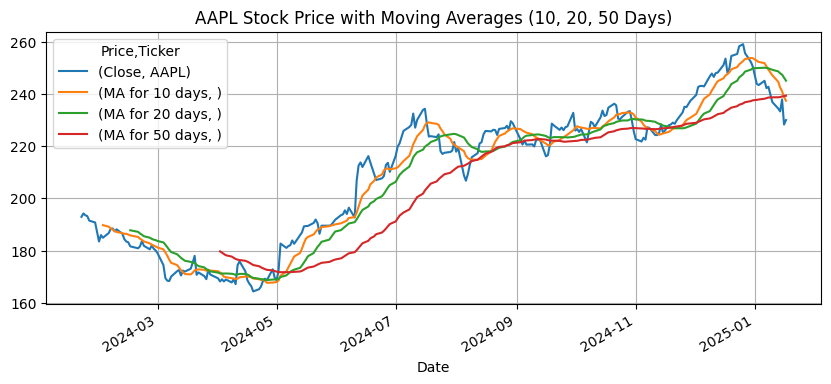

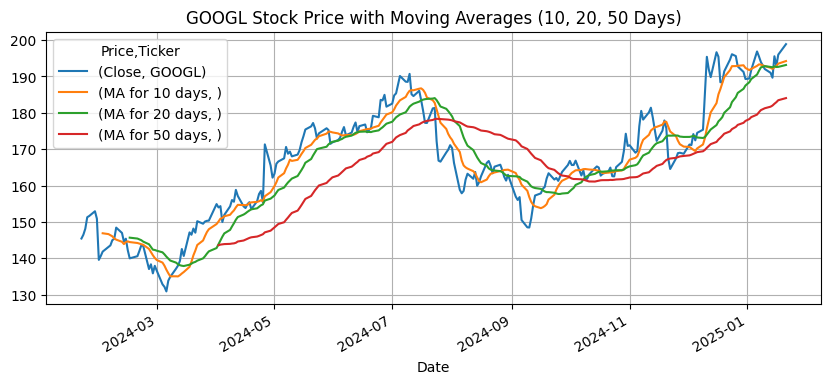

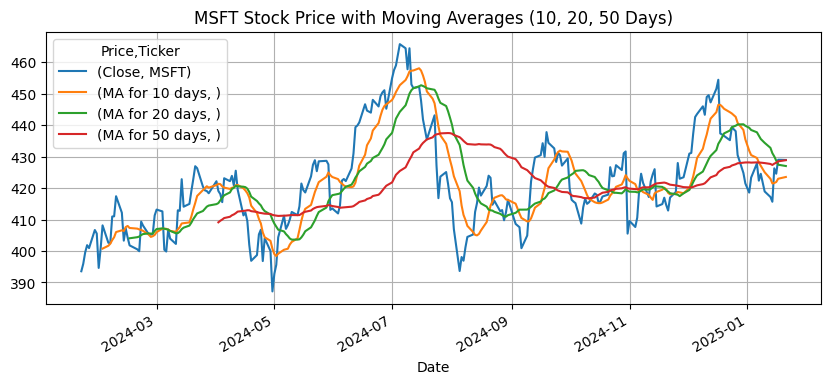

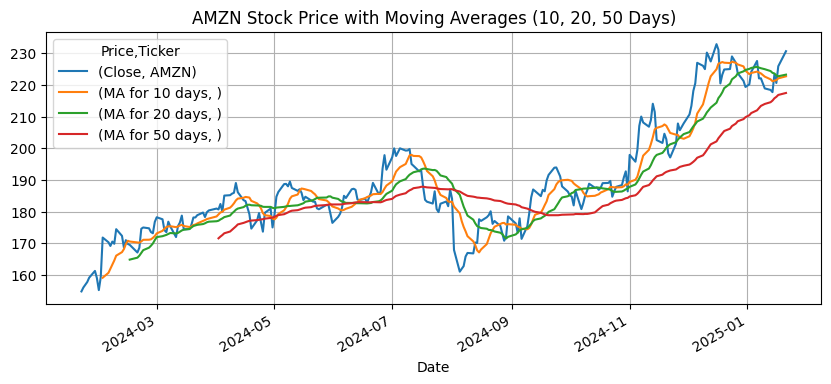

In [15]:
stock_data['AAPL'][['Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(legend = True, figsize=(10,4)).grid(True)
plt.title('AAPL Stock Price with Moving Averages (10, 20, 50 Days)')
plt.show()

stock_data['GOOGL'][['Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(legend = True, figsize=(10,4)).grid(True)
plt.title('GOOGL Stock Price with Moving Averages (10, 20, 50 Days)')
plt.show()

stock_data['MSFT'][['Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(legend = True, figsize=(10,4)).grid(True)
plt.title('MSFT Stock Price with Moving Averages (10, 20, 50 Days)')
plt.show()

stock_data['AMZN'][['Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(legend = True, figsize=(10,4)).grid(True)
plt.title('AMZN Stock Price with Moving Averages (10, 20, 50 Days)')
plt.show()

## Insights
###  * Looking at Jan 2025


- The short-term moving averages (10-day) cross above the longer-term moving averages (50-day) except for MSFT, it could be signal an upward trend (bullish).
- The 'Close' price is above a moving average (especially the 50-day) most of the time in 4 stocks, it indicates a  quite strong uptrend in stock price. 

In [16]:
# Create an empty DataFrame to store the closing values
closing_df = pd.DataFrame()

# Loop through each stock and fetch the data
for stock in tech_list:
    data = yf.download(stock, start=start, end=end)  # Download stock data
    closing_df[stock] = data['Close']  # Add the 'Close' column to the DataFrame


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
closing_df.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-01-22,192.944748,145.462692,393.566956,154.779999
2024-01-23,194.228455,146.508881,395.939209,156.020004
2024-01-24,193.551773,148.162903,399.572021,156.869995
2024-01-25,193.223389,151.321426,401.864899,157.750000
2024-01-26,191.481918,151.640289,400.931854,159.119995


In [18]:
tech_daily_returns = closing_df.pct_change()

In [19]:
tech_daily_returns.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-01-22,NaN,NaN,NaN,NaN
2024-01-23,0.006653,0.007192,0.006028,0.008011
2024-01-24,-0.003484,0.011290,0.009175,0.005448
2024-01-25,-0.001697,0.021318,0.005738,0.005610
2024-01-26,-0.009013,0.002107,-0.002322,0.008685


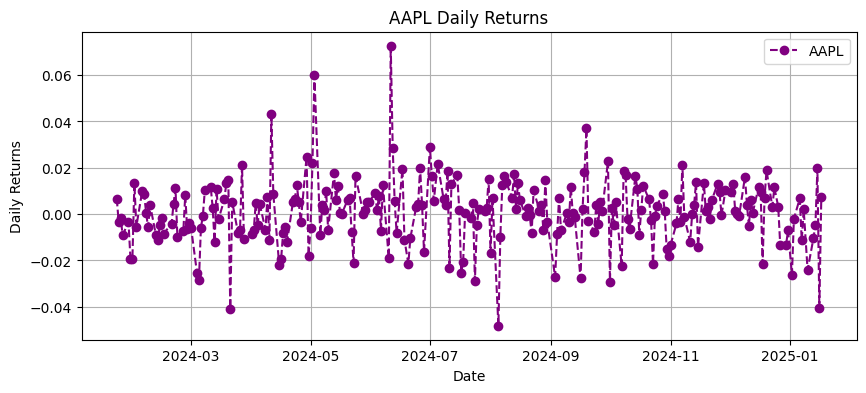

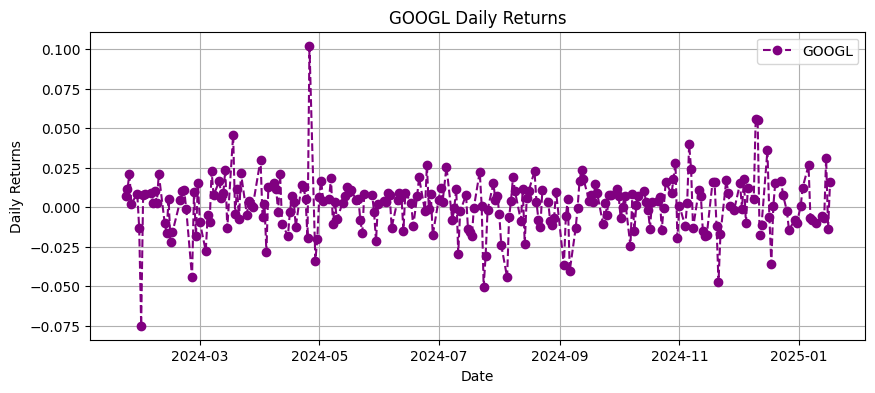

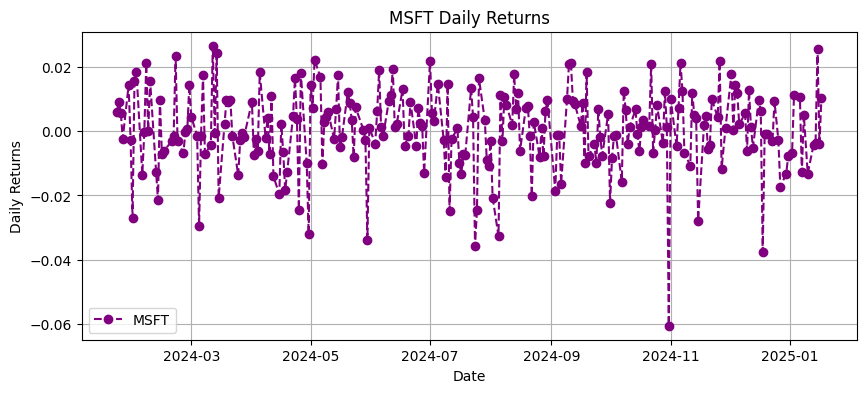

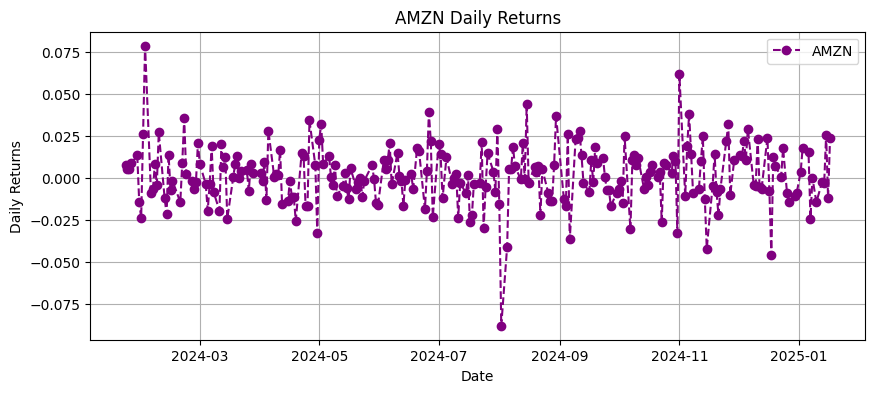

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(tech_daily_returns.index,tech_daily_returns['AAPL'],label = 'AAPL',marker='o',linestyle='--',color='purple')
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tech_daily_returns.index,tech_daily_returns['GOOGL'],label = 'GOOGL',marker='o',linestyle='--',color='purple')
plt.title('GOOGL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tech_daily_returns.index,tech_daily_returns['MSFT'],label = 'MSFT',marker='o',linestyle='--',color='purple')
plt.title('MSFT Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(tech_daily_returns.index,tech_daily_returns['AMZN'],label = 'AMZN',marker='o',linestyle='--',color='purple')
plt.title('AMZN Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

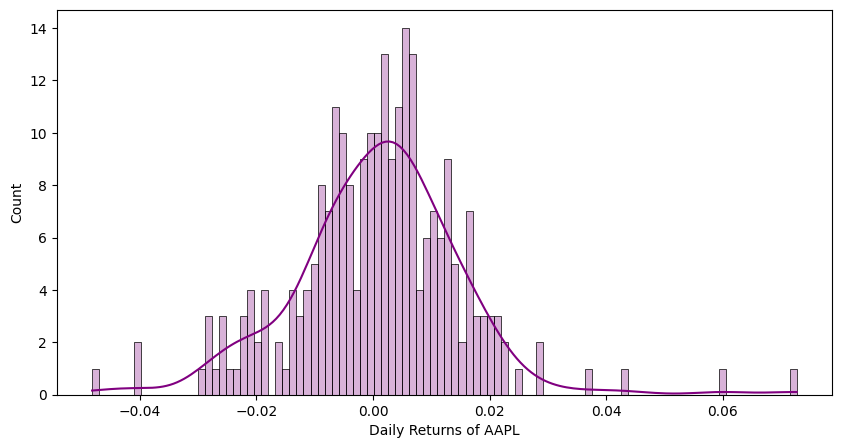

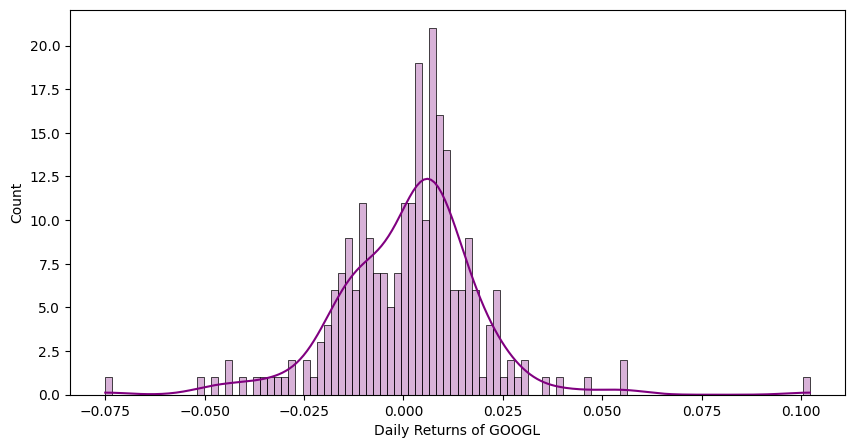

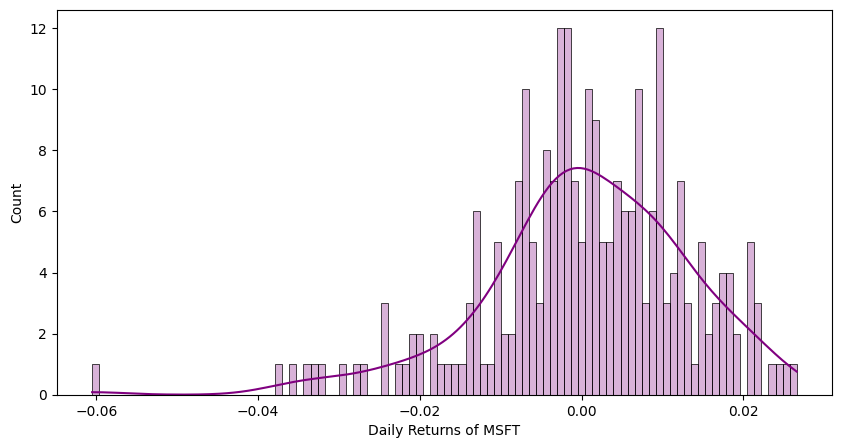

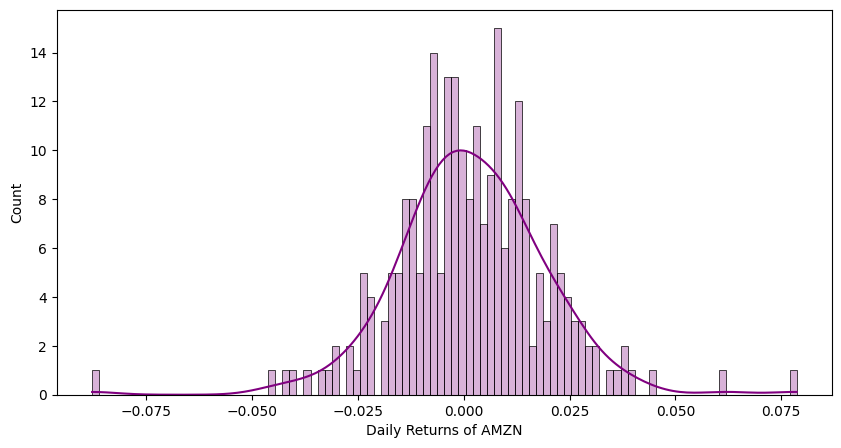

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(tech_daily_returns['AAPL'],kde=True,bins=100,color ='purple',alpha=0.3)
plt.xlabel('Daily Returns of AAPL')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(tech_daily_returns['GOOGL'],kde=True,bins=100,color ='purple',alpha=0.3)
plt.xlabel('Daily Returns of GOOGL')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(tech_daily_returns['MSFT'],kde=True,bins=100,color ='purple',alpha=0.3)
plt.xlabel('Daily Returns of MSFT')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(tech_daily_returns['AMZN'],kde=True,bins=100,color ='purple',alpha=0.3)
plt.xlabel('Daily Returns of AMZN')
plt.show()

## Insights

### 1. AAPL (Apple Inc.):
- Symmetry: The distribution is relatively symmetric, centered around 0% daily return. This suggests that positive and negative returns are fairly balanced.
- Volatility: Most returns fall within the range of -2% to +2%, with a few outliers extending beyond +6% and -4%. This indicates moderate volatility, with occasional extreme returns.
- Risk-Reward Profile: The overall stability makes AAPL a relatively safer stock for consistent returns, though outliers need attention.
### GOOGL (Alphabet Inc.):
- Symmetry: The distribution is nearly symmetric, with the peak around 0% daily return. However, the tails are slightly heavier, indicating a potential for occasional extreme returns.
- Volatility: Returns are more spread out compared to AAPL, with a range extending to approximately -7.5% to +10%. This suggests higher volatility compared to the other stocks.
- Risk-Reward Profile: While there are more frequent moderate returns, the heavy tails indicate the need for risk management, as the stock is more prone to significant price swings.
### MSFT (Microsoft Corp.):
- Symmetry: The distribution is slightly positively skewed, with more frequent small positive returns compared to negative ones.
- Volatility: Most returns lie within the -2% to +2% range, with few outliers extending to approximately -6% on the negative side. This suggests moderate volatility.
- Risk-Reward Profile: The slight positive skew implies potential for higher gains, with less frequent extreme losses. MSFT may appeal to investors looking for stability with occasional positive surprises.
### AMZN (Amazon Inc.):
- Symmetry: The distribution is symmetric, with the highest frequency around 0% daily return, similar to AAPL.
- Volatility: The range is slightly wider, with returns mostly between -5% and +5%, and a few extreme returns reaching beyond +7.5% or -7.5%. This indicates higher volatility than AAPL and MSFT, but slightly less than GOOGL.
- Risk-Reward Profile: AMZN offers a balance of stability and risk, making it suitable for moderate-risk investors. However, its wider range of returns should be monitored for sudden price movements.


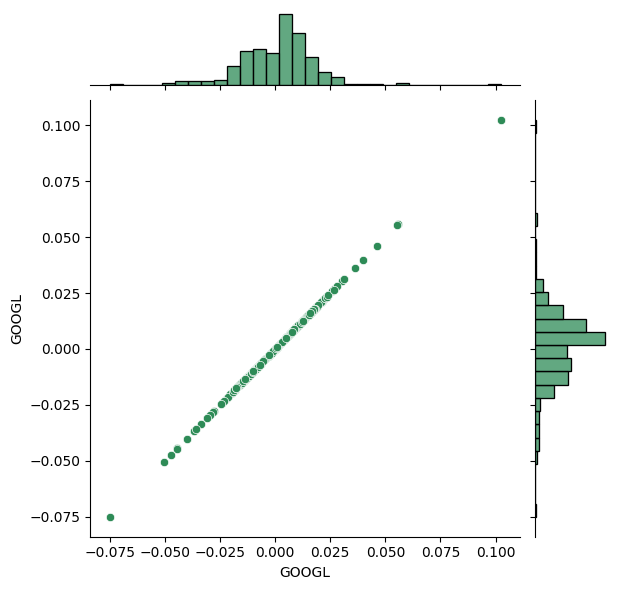

In [22]:
sns.jointplot(tech_daily_returns,x='GOOGL',y='GOOGL',kind='scatter',color='seagreen')

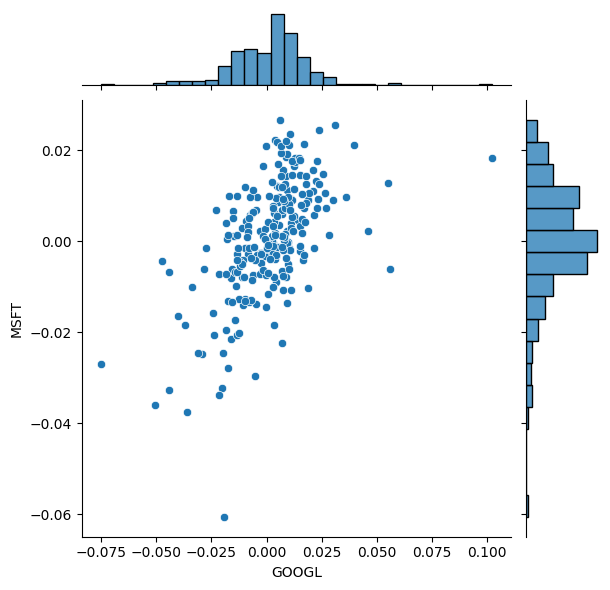

In [23]:
sns.jointplot(tech_daily_returns,x='GOOGL',y='MSFT',kind='scatter')

In [24]:
tech_daily_returns.head()

,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-01-22,NaN,NaN,NaN,NaN
2024-01-23,0.006653,0.007192,0.006028,0.008011
2024-01-24,-0.003484,0.011290,0.009175,0.005448
2024-01-25,-0.001697,0.021318,0.005738,0.005610
2024-01-26,-0.009013,0.002107,-0.002322,0.008685


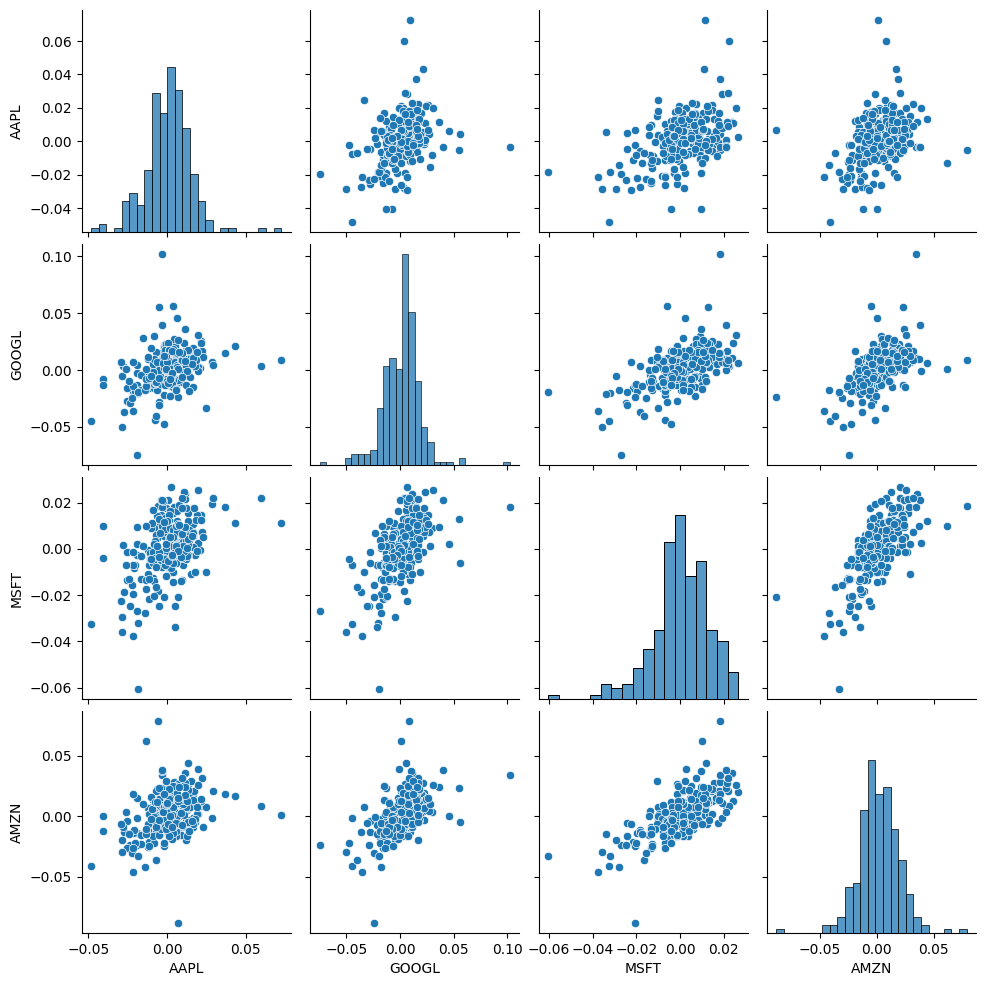

In [25]:
sns.pairplot(tech_daily_returns.dropna())

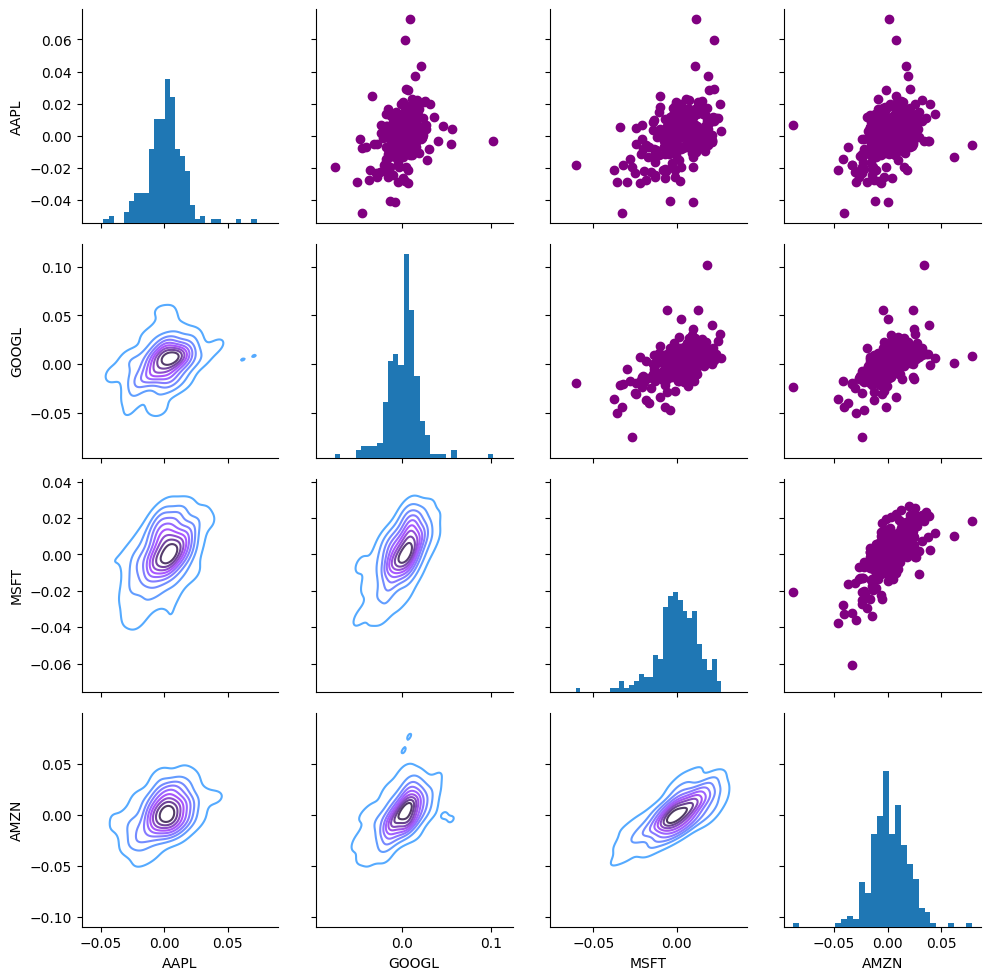

In [26]:
returns_fig = sns.PairGrid(tech_daily_returns.dropna())

returns_fig.map_upper(plt.scatter,color='purple')

returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

returns_fig.map_diag(plt.hist,bins=30)

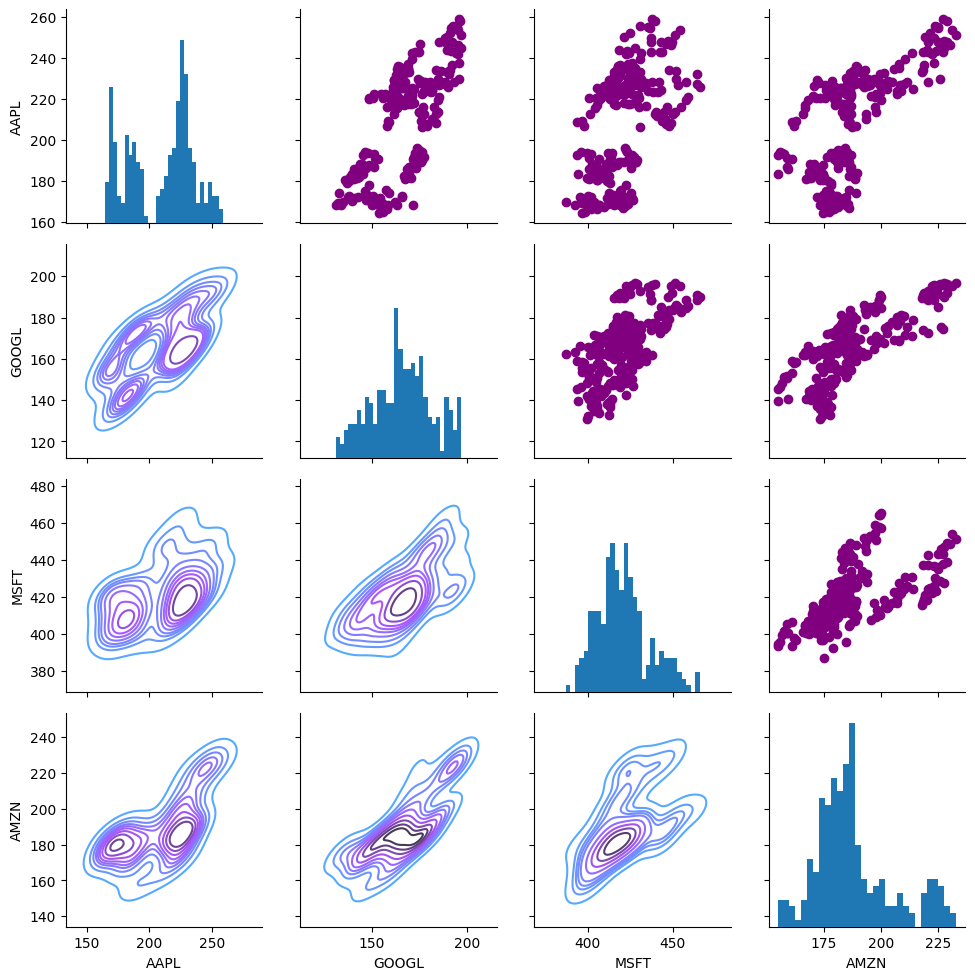

In [27]:
returns_fig = sns.PairGrid(closing_df)

returns_fig.map_upper(plt.scatter,color='purple')

returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

returns_fig.map_diag(plt.hist,bins=30)

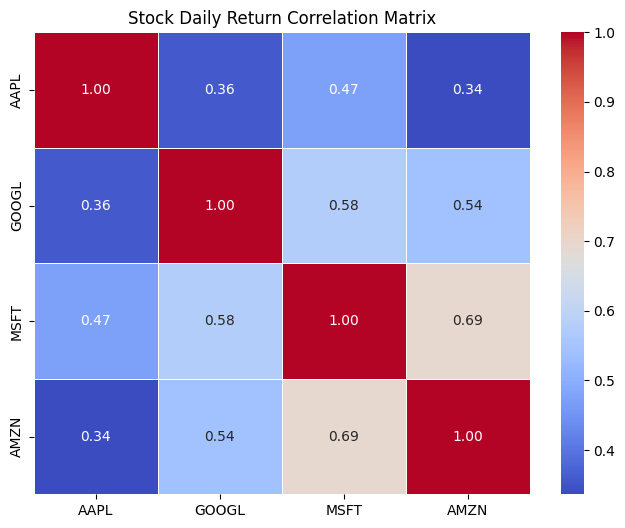

In [28]:
df_corr = pd.DataFrame(tech_daily_returns)
df_corr = df_corr.dropna().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Stock Daily Return Correlation Matrix")
plt.show()

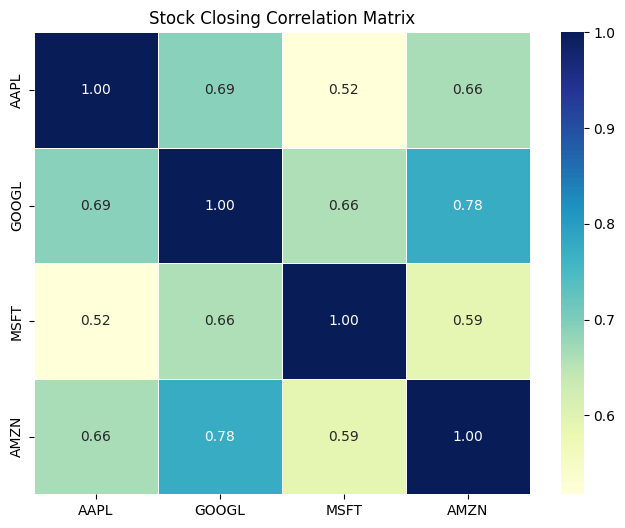

In [29]:
corr_close = closing_df.dropna().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_close, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Stock Closing Correlation Matrix")
plt.show()

# Risk Analysis

### (In this analysis, I am comparing the expected return with the standard deviation of the daily returns)

In [30]:
rets = tech_daily_returns.dropna()
rets.head()


,AAPL,GOOGL,MSFT,AMZN
Date,,,,
2024-01-23,0.006653,0.007192,0.006028,0.008011
2024-01-24,-0.003484,0.011290,0.009175,0.005448
2024-01-25,-0.001697,0.021318,0.005738,0.005610
2024-01-26,-0.009013,0.002107,-0.002322,0.008685
2024-01-29,-0.003586,0.008673,0.014334,0.013449


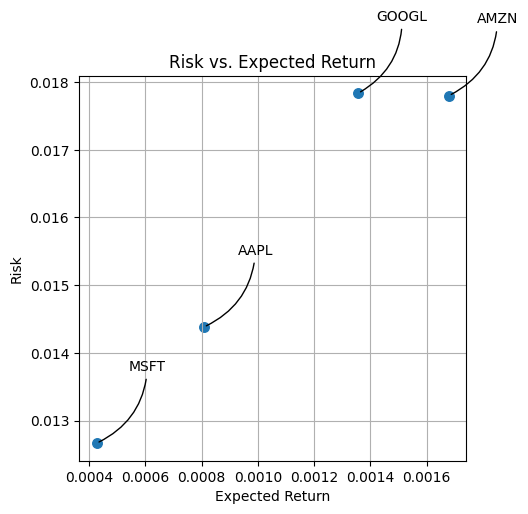

In [31]:
area = np.pi*15

plt.figure(figsize=(5, 5))

plt.scatter(rets.mean(),rets.std(), s=area)

plt.xlabel('Expected Return')

plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (50, 50),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        arrowprops = dict(arrowstyle = '-', connectionstyle = 'arc3,rad=-0.3'))
plt.grid(True)
plt.title("Risk vs. Expected Return")
plt.show()

## Insights
### Cluster Analysis
- AMZN and GOOGL: These assets show relatively higher risk and expected return compared to others. They might be suitable for investors with a higher risk tolerance.
- AAPL: Positioned in the middle of the graph, it shows moderate risk and return, which could appeal to more balanced investors.
- MSFT: Exhibits the lowest risk and expected return among the group, potentially appealing to risk-averse investors.

### Portfolio Implications:

Investors might prefer assets like AAPL if they seek moderate risk with decent returns, while those seeking aggressive growth might lean toward AMZN or GOOGL.


# Value at Risk
### Value at risk using "bootstrap" method

<Axes: xlabel='AAPL', ylabel='Count'>

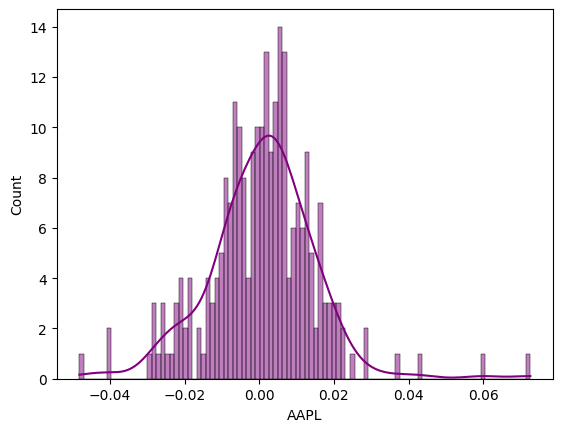

In [32]:
sns.histplot(tech_daily_returns['AAPL'],kde=True,bins=100,color='purple')

In [33]:
round(rets['AAPL'].quantile(0.05),3)

np.float64(-0.023)

 The 0.05 empirical quantile of daily return of AAPL is at -0.022. That means that with 95% confidence, our worst daily loss will not exceed 2.2% If we have 1 million dollar investment, our one-day 5% VaR is 0.022 * 1,000,000 = $22,000


In [34]:
days = 365

dt=1/days

mu=rets.mean()['GOOGL']

sigma =rets.std()['GOOGL']

In [35]:
def stock_monte_carlo(start_price,days,mu,sigma):
    
    price = np.zeros(days)
    price[0] = start_price
    
    shock = np.zeros(days)
    drift = np.zeros(days)
    
    for x in range(1,days):
        shock[x] = np.random.normal(loc=mu*dt,scale=sigma*np.sqrt(dt))
        
        drift[x] = mu * dt
        
        price[x] = price[x-1] +(price[x-1] * (drift[x] + shock[x]))
        
    return price

In [36]:
stock_data['GOOGL'].head()

Price,Close,High,Low,Open,Volume,MA for 10 days,MA for 20 days,MA for 50 days
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL,,,
Date,,,,,,,,
2024-01-22,145.462692,147.854017,145.313225,146.568684,32200400,NaN,NaN,NaN
2024-01-23,146.508881,146.648374,144.974450,145.363041,21636100,NaN,NaN,NaN
2024-01-24,148.162903,149.308758,147.565079,148.003477,25233500,NaN,NaN,NaN
2024-01-25,151.321426,152.497172,148.999841,149.527940,29149100,NaN,NaN,NaN
2024-01-26,151.640289,151.989016,150.464544,150.554230,26115500,NaN,NaN,NaN


Text(0.5, 1.0, 'Monte Carlo Analysis for Google Stock')

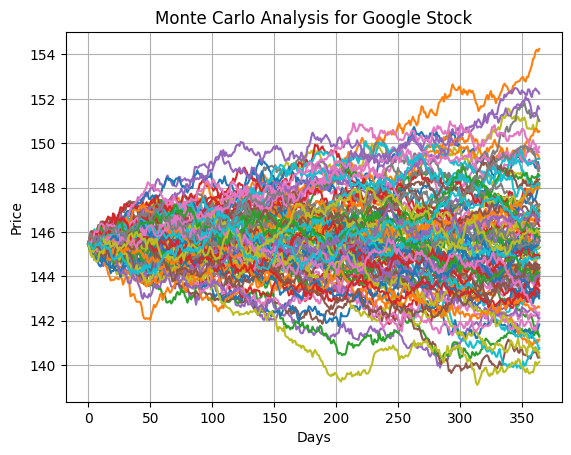

In [37]:
start_price = closing_df.iloc[0]['GOOGL']

for run in range(100):
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))
    
plt.xlabel('Days')
plt.ylabel('Price')
plt.grid(True)
plt.title('Monte Carlo Analysis for Google Stock')

In [38]:
# Set a large numebr of runs
runs = 10000

# Create an empty matrix to hold the end price data
simulations = np.zeros(runs)

# Set the print options of numpy to only display 0-5 points from an array to suppress output
np.set_printoptions(threshold=5)

for run in range(runs):    
    # Set the simulation data point as the last stock price for that run
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1];

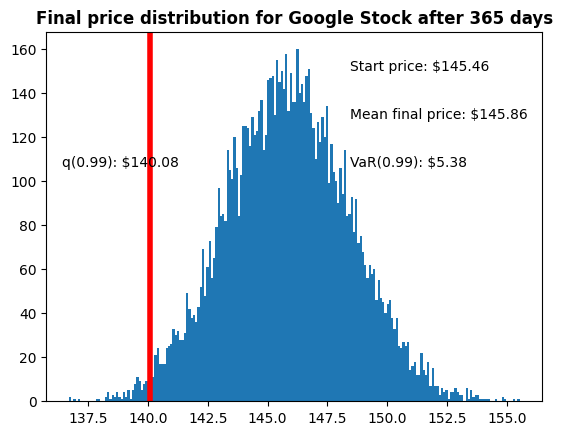

In [39]:
# Now we'lll define q as the 1% empirical qunatile, this basically means that 99% of the values should fall between here
q = np.percentile(simulations, 1)
    
# Now let's plot the distribution of the end prices
plt.hist(simulations,bins=200)

# Using plt.figtext to fill in some additional information onto the plot

# Starting Price
plt.figtext(0.6, 0.8, s="Start price: $%.2f" %start_price)
# Mean ending price
plt.figtext(0.6, 0.7, "Mean final price: $%.2f" % simulations.mean())

# Variance of the price (within 99% confidence interval)
plt.figtext(0.6, 0.6, "VaR(0.99): $%.2f" % (start_price - q,))

# Display 1% quantile
plt.figtext(0.15, 0.6, "q(0.99): $%.2f" % q)

# Plot a line at the 1% quantile result
plt.axvline(x=q, linewidth=4, color='r')

# Title
plt.title(u"Final price distribution for Google Stock after %s days" % days, weight='bold');

## Insights

Every initial stock your purchase on Google Stock, you are putting $5.37 at risk 99% of the time from our Monte Carlo Simulation